# Seminar 2

### 1. Overview

The visualization aims to compare the monthly sales performance of the "SlicerDicers" brand against eight other competing brands over a six-month period (July–December). The objective is to identify market standing and growth trends relative to the primary product.

### 2. Explanation of Data
- time-series data combined with categorical data (brand names)
- It uses three dimensions: Time (Months), Categorical (9 Brands), and Quantitative (Sales in Dollars).
The dataset appears to be internal corporate sales data, though the original presentation makes the raw values difficult to extract accurately.
### 3. Explanation of Visualization Techniques
 - the original image depicts a grouped bar chart, that uses clusters of nine bars per month
 - the proposed fix shows subplots in which there are time-series line plots using an Index/Ratio technique (Brand saled divided by SlicerDicers Sales)
### 4. Effectiveness
- The original grouped bar chart fails because of visual clutter. With 54 bars on one screen, it is very difficult to track a single brand's trend across the six months.
- Proposed: By isolating each brand into its own subplot, the user can instantly recognize the shape of the data. Whether a brand is growing or shrinking, is immediately visible.
### 5. Integrity
- Original: While the axes are technically accurate, stacking nine different brands together makes it nearly impossible to see when a specific product's sales dip or spike. The "SlicerDicers" data is hidden in the middle of each group, making it hard to use as a benchmark, which is the stated goal of the chart.

- Proposed: by normalizing the data to a 100% baseline (the SlicerDicers line), the visualization removes the bias of scale. It doesn't just show who sold more, it shows how much more or less they sold relative to the target, providing a fair comparison.

### 6. Design
- Original: Poorly designed, it has a high data-ink ratio with havey gridlines and a massive, distracting legend
- Proposed: The use of sorting, ascending by monthly average creates a hierarchy, ranking competitors from the lowest performances to the market leaders. 


![fig_1](sales_per_month.png)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
data = {
    "Month": ["July", "August", "September", "October", "November", "December"],
    "AhNuts": [140000, 145000, 165000, 185000, 175000, 200000],
    "NervousNellies": [90000, 95000, 95000, 110000, 95000, 110000],
    "RingaDinngies": [50000, 55000, 55000, 100000, 55000, 100000],
    "RoundTuits": [575000, 555000, 385000, 575000, 480000, 575000],
    "SlicerDicers": [295000, 240000, 145000, 265000, 240000, 265000],
    "SweetNuthins": [110000, 70000, 55000, 80000, 70000, 80000],
    "ThingamaGigs": [50000, 100000, 95000, 95000, 70000, 100000],
    "Whatchamacallits": [75000, 90000, 70000, 85000, 75000, 75000],
    "WileyWidgets": [50000, 55000, 60000, 95000, 90000, 125000]
}

In [3]:
df = pd.DataFrame(data)
df.head()

,Month,AhNuts,NervousNellies,RingaDinngies,RoundTuits,SlicerDicers,SweetNuthins,ThingamaGigs,Whatchamacallits,WileyWidgets
0,July,140000,90000,50000,575000,295000,110000,50000,75000,50000
1,August,145000,95000,55000,555000,240000,70000,100000,90000,55000
2,September,165000,95000,55000,385000,145000,55000,95000,70000,60000
3,October,185000,110000,100000,575000,265000,80000,95000,85000,95000
4,November,175000,95000,55000,480000,240000,70000,70000,75000,90000


In [4]:
df_brands = df.melt(id_vars=["Month"], var_name="Brand", value_name="Sales")
df_brands.head()

,Month,Brand,Sales
0,July,AhNuts,140000
1,August,AhNuts,145000
2,September,AhNuts,165000
3,October,AhNuts,185000
4,November,AhNuts,175000


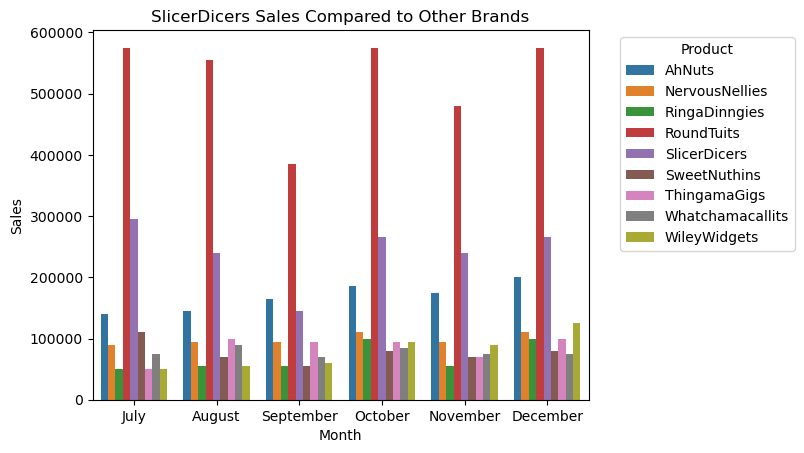

In [5]:
sns.barplot(data=df_brands, x="Month", y="Sales", hue="Brand")
plt.title("SlicerDicers Sales Compared to Other Brands")
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc='upper left')

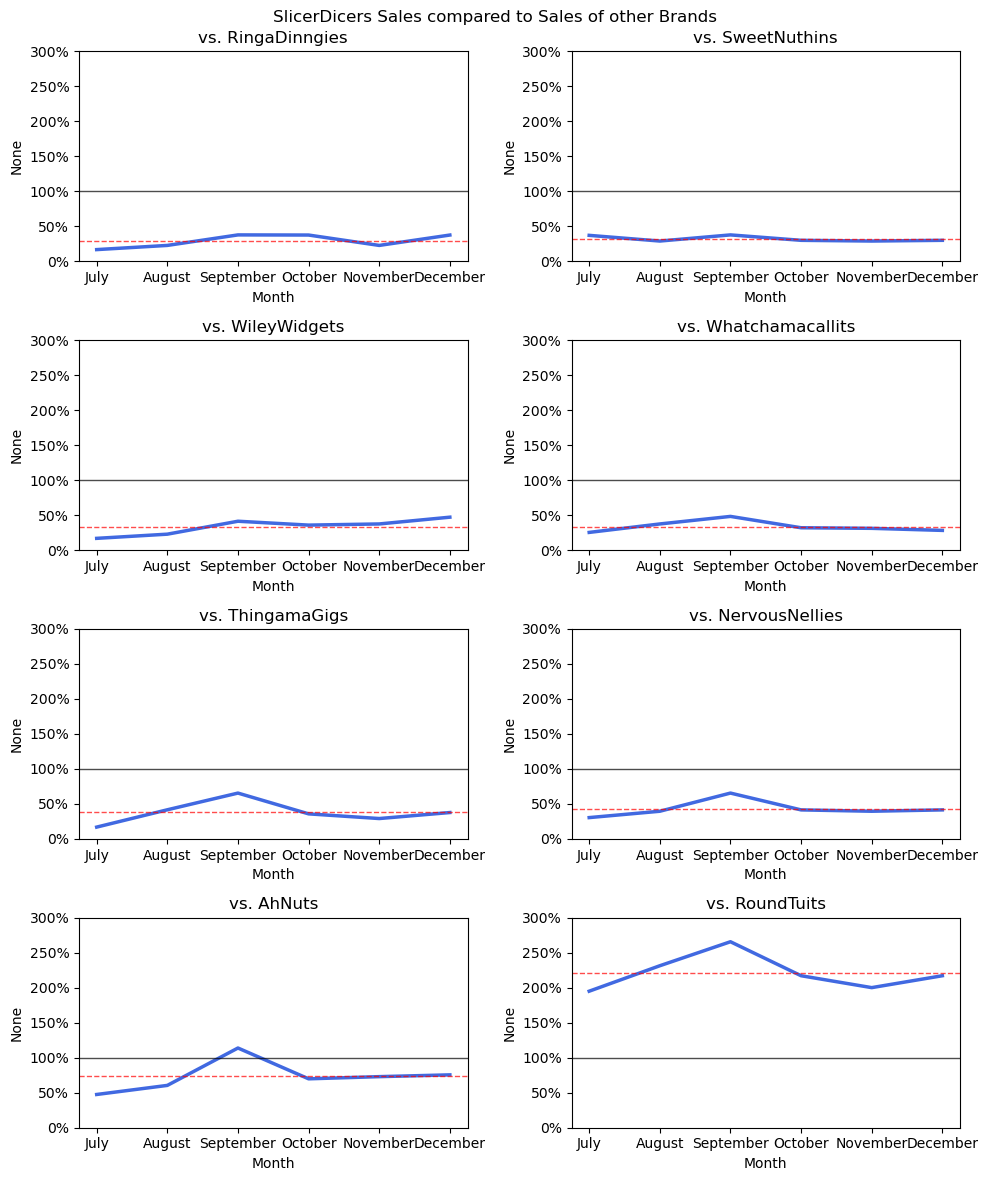

In [6]:
other_brands = list(filter(lambda x: x != "SlicerDicers", df_brands["Brand"].unique()))
brand_data = []

for brand in other_brands:
    ratio = (df[brand] / df["SlicerDicers"]) * 100
    brand_data.append((brand, ratio))

brand_data_sorted = sorted(brand_data, key=lambda x: x[1].mean())

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.flatten()

for i, (brand, ratio) in enumerate(brand_data_sorted):
    sns.lineplot(x=df["Month"], y=ratio, ax=axes[i], color='royalblue', linewidth=2.5)
    
    avg_val = ratio.mean()
    axes[i].axhline(avg_val, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Avg: {avg_val:.1f}%')    
    
    axes[i].axhline(100, color='black', linewidth=1, alpha=0.7)
    axes[i].set_title(f"vs. {brand}")
    axes[i].set_ylim(0, 300)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    
plt.suptitle("SlicerDicers Sales compared to Sales of other Brands")
plt.tight_layout()
plt.show()

In [ ]:
# !jupyter nbconvert --output 's02_notebook_Ciobanu_Sergiu_Tudor.html' --to html seminar_2.ipynb

[NbConvertApp] Converting notebook seminar_2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 523782 bytes to s02_notebook_Ciobanu_Sergiu_Tudor.html
